# Recalibrate livestock carrying capacity and soil fertilizer demand

Two BAU input adjustments bundled into a single notebook. Both apply a linear ramp starting at 1.0 in the inventory reference year (2023) and ending at a higher value in 2050; years before 2023 stay at 1.0.

## 1. Livestock carrying capacity (`scalar_lvst_carrying_capacity`)

**Problem.** In BAU, domestic livestock populations shrink ~18% from 2023 to 2050 for all pasture-grazing species (sheep, goats, cattle, horses, mules) even though demand grows +53%. Pasture area declines from 12.34 M ha (2023) to 10.10 M ha (2050) under the Markov land-use transition matrix, and `scalar_lvst_carrying_capacity` stays at 1.0 — so the pre-reallocation livestock cap falls 1:1 with pasture area. With `set_lndu_reallocation_factor_to_zero: true`, there is no mechanism to expand pasture to meet demand, so enteric CH4 and LSMM emissions fall in BAU.

**Fix.** Ramp to **1.22** in 2050 to exactly offset the −18.1% pasture loss and keep livestock populations flat. (Higher values 1.35–1.50 produce modest growth consistent with MENA pastoral intensification.)

## 2. Soil fertilizer demand (`demscalar_soil_fertilizer_n_per_area`)

**Problem.** In BAU, 3.C.4 Direct N2O from managed soils drops ~28% (0.655 → 0.474 MtCO2e) from 2023 to 2050. Two mechanisms: (a) `mineral_soils` N2O (FSOM = soil organic C mineralization) is a transient stock-change flux that decays −62% as SOC approaches post-conversion equilibrium — IPCC-compliant behavior; (b) total area-driven N demand only grows +6% (cropland area nearly flat) while organic manure N grows +43% once the livestock fix is applied, so synthetic fertilizer is fully crowded out (`synthetic = max(0, total_area_driven − organic) → 0` by 2050), capping `emission_co2e_n2o_soil_fertilizer` growth at +7%.

**Fix.** Ramp to **1.35** in 2050 to lift total N applied per hectare, which (i) grows N2O from fertilizer roughly linearly with the scalar and (ii) keeps some synthetic fertilizer in the mix after the manure crowd-out. The residual FSOM decay is legitimate and left alone.

## Scope

Both changes only affect flux scalars. With `yrf=0` in the config, neither feeds back into land-use areas, so forestland, croplands, grasslands and wetlands are unaffected.

## Output

Writes `sisepuede_raw_inputs_recalibrated_lvst_cc_soil_fert.csv` ready to be referenced from `config.yaml::ssp_input_file_name`.

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [26]:
# Parameters
INPUT_FILE = "sisepuede_raw_inputs_recalibrated_electricity_demand.csv"
OUTPUT_FILE = "sisepuede_raw_inputs_recalibrated_lvst_cc_soil_fert.csv"

BASE_YEAR = 2015          # time_period=0 corresponds to this calendar year
ANCHOR_YEAR = 2023        # inventory reference year; ramp starts here
END_YEAR = 2050           # ramp endpoint

# --- Ramp 1: livestock carrying capacity ---
# 1.22 keeps livestock pop flat (offsets -18.1% pasture loss).
# Use 1.35-1.50 for modest BAU growth consistent with pastoral intensification.
LVST_CC_COL = "scalar_lvst_carrying_capacity"
LVST_CC_TARGET_2050 = 1.3

# --- Ramp 2: soil fertilizer demand per area ---
# 1.35 lifts total N applied and grows 3.C.4 Direct N2O roughly linearly.
# Use 1.25 for more conservative, 1.50 for clearer growth.
SOIL_FERT_COL = "demscalar_soil_fertilizer_n_per_area"
SOIL_FERT_TARGET_2050 = 1.45

In [27]:
df = pd.read_csv(INPUT_FILE)
# The input already has a 'year' column equal to time_period + BASE_YEAR; no helper needed.
assert "year" in df.columns, "expected 'year' column in the raw input"
assert (df["year"] == df["time_period"] + BASE_YEAR).all(), "year != time_period + base year"
for col in (LVST_CC_COL, SOIL_FERT_COL):
    assert col in df.columns, f"{col} not found in input"
print(f"Shape: {df.shape}")
print(f"Year range: {df['year'].min()}-{df['year'].max()}")
df[["year", LVST_CC_COL, SOIL_FERT_COL]].head(10)

Shape: (36, 2441)
Year range: 2015-2050


,year,scalar_lvst_carrying_capacity,demscalar_soil_fertilizer_n_per_area
0,2015,1.0,1.0
1,2016,1.0,1.0
2,2017,1.0,1.0
3,2018,1.0,1.0
4,2019,1.0,1.0
5,2020,1.0,1.0
6,2021,1.0,1.0
7,2022,1.0,1.0
8,2023,1.0,1.0
9,2024,1.0,1.0


In [28]:
# Sanity check: confirm both scalars are currently constant at 1.0
print("Current scalars (should both be constant at 1.0):")
print(df[["year", LVST_CC_COL, SOIL_FERT_COL]].set_index("year").T.to_string())

Current scalars (should both be constant at 1.0):
year                                  2015  2016  2017  2018  2019  2020  2021  2022  2023  2024  2025  2026  2027  2028  2029  2030  2031  2032  2033  2034  2035  2036  2037  2038  2039  2040  2041  2042  2043  2044  2045  2046  2047  2048  2049  2050
scalar_lvst_carrying_capacity          1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0
demscalar_soil_fertilizer_n_per_area   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0   1.0


In [29]:
# Build the new trajectories:
#   year <= ANCHOR_YEAR  -> 1.0 (historical anchor)
#   ANCHOR_YEAR < year <= END_YEAR -> linear interpolation from 1.0 to target
def build_ramp(years, anchor_year, end_year, target):
    years = np.asarray(years, dtype=float)
    ramp = np.ones_like(years)
    mask = years > anchor_year
    frac = (years[mask] - anchor_year) / (end_year - anchor_year)
    frac = np.clip(frac, 0.0, 1.0)
    ramp[mask] = 1.0 + (target - 1.0) * frac
    return ramp

df_new = df.copy()
df_new[LVST_CC_COL] = build_ramp(
    df_new["year"].values, ANCHOR_YEAR, END_YEAR, LVST_CC_TARGET_2050,
)
df_new[SOIL_FERT_COL] = build_ramp(
    df_new["year"].values, ANCHOR_YEAR, END_YEAR, SOIL_FERT_TARGET_2050,
)

preview_years = [2015, 2020, 2023, 2025, 2030, 2035, 2040, 2045, 2050]
preview = df_new[df_new["year"].isin(preview_years)][["year", LVST_CC_COL, SOIL_FERT_COL]]
preview.set_index("year").T

year,2015,2020,2023,2025,2030,2035,2040,2045,2050
scalar_lvst_carrying_capacity,1.0,1.0,1.0,1.022222,1.077778,1.133333,1.188889,1.244444,1.30
demscalar_soil_fertilizer_n_per_area,1.0,1.0,1.0,1.033333,1.116667,1.200000,1.283333,1.366667,1.45


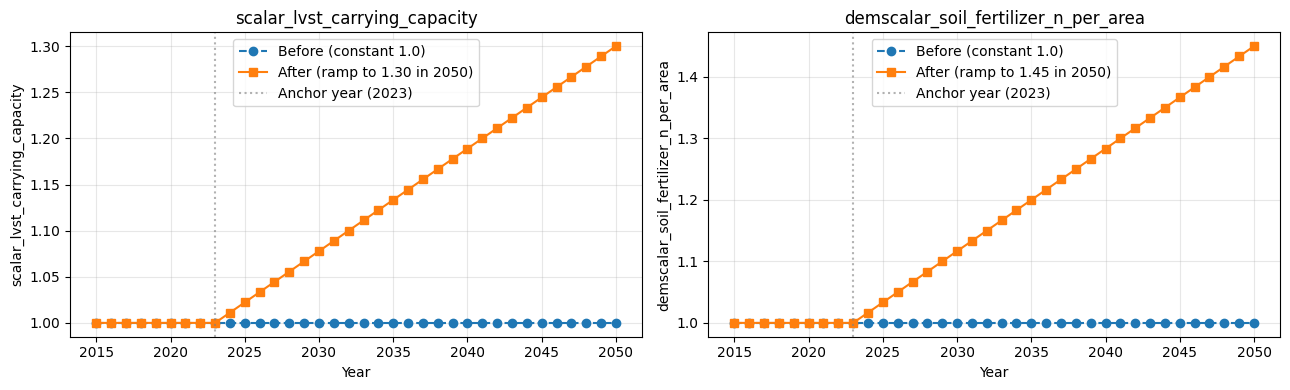

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, col, target in [
    (axes[0], LVST_CC_COL, LVST_CC_TARGET_2050),
    (axes[1], SOIL_FERT_COL, SOIL_FERT_TARGET_2050),
]:
    ax.plot(df["year"], df[col], label="Before (constant 1.0)", linestyle="--", marker="o")
    ax.plot(df_new["year"], df_new[col], label=f"After (ramp to {target:.2f} in {END_YEAR})", marker="s")
    ax.axvline(ANCHOR_YEAR, color="gray", linestyle=":", alpha=0.6, label=f"Anchor year ({ANCHOR_YEAR})")
    ax.set_xlabel("Year")
    ax.set_ylabel(col)
    ax.set_title(col)
    ax.grid(True, alpha=0.3)
    ax.legend()

plt.tight_layout()

In [31]:
# --- Expected impact: livestock ---
# Uses 2023 vs 2050 pasture areas from the most recent BAU run: 12.34 M ha -> 10.10 M ha (-18.1%).
pasture_2023 = 12_337_260.59
pasture_2050 = 10_104_142.53
area_ratio = pasture_2050 / pasture_2023

cc_2023 = float(df_new.loc[df_new["year"] == ANCHOR_YEAR, LVST_CC_COL].iloc[0])
cc_2050 = float(df_new.loc[df_new["year"] == END_YEAR, LVST_CC_COL].iloc[0])

supportable_ratio = (cc_2050 * pasture_2050) / (cc_2023 * pasture_2023)
print("Livestock carrying capacity")
print(f"  Pasture area 2050/2023:                        {area_ratio:.3f}")
print(f"  Carrying-capacity scalar 2050/2023:            {cc_2050 / cc_2023:.3f}")
print(f"  Implied supportable-livestock ratio 2050/2023: {supportable_ratio:.3f}")
print(f"    -> {(supportable_ratio - 1) * 100:+.1f}% change vs. 2023 for pasture-grazing species")

# --- Expected impact: soil fertilizer N2O ---
# emission_co2e_n2o_soil_fertilizer scales ~linearly with total N applied, which scales
# linearly with demscalar_soil_fertilizer_n_per_area. Mineral_soils (FSOM) decay is an
# independent transient and is NOT affected.
# Reference decomposition (raw BAU baseline): fertilizer=0.38, mineral=0.08, organic=0.01, total=0.47 in 2050.
# Inventory target at 2023: 0.655 MtCO2e.
fert_2023 = float(df_new.loc[df_new["year"] == ANCHOR_YEAR, SOIL_FERT_COL].iloc[0])
fert_2050 = float(df_new.loc[df_new["year"] == END_YEAR, SOIL_FERT_COL].iloc[0])

base_fertilizer_2050 = 0.38   # decomposed BAU w/o this fix
base_mineral_2050    = 0.085
base_organic_2050    = 0.015
base_total_2050      = base_fertilizer_2050 + base_mineral_2050 + base_organic_2050

proj_fertilizer_2050 = base_fertilizer_2050 * (fert_2050 / fert_2023)
proj_total_2050 = proj_fertilizer_2050 + base_mineral_2050 + base_organic_2050

print()
print("Soil fertilizer N2O (3.C.4 Direct)")
print(f"  demscalar_soil_fertilizer_n_per_area 2050/2023: {fert_2050 / fert_2023:.3f}")
print(f"  Current BAU 2050 total (decomposed):            {base_total_2050:.3f} MtCO2e")
print(f"  Projected BAU 2050 total with ramp:             {proj_total_2050:.3f} MtCO2e")
print(f"    -> {(proj_total_2050 / 0.655 - 1) * 100:+.1f}% vs. 2023 inventory (0.655)")

Livestock carrying capacity
  Pasture area 2050/2023:                        0.819
  Carrying-capacity scalar 2050/2023:            1.300
  Implied supportable-livestock ratio 2050/2023: 1.065
    -> +6.5% change vs. 2023 for pasture-grazing species

Soil fertilizer N2O (3.C.4 Direct)
  demscalar_soil_fertilizer_n_per_area 2050/2023: 1.450
  Current BAU 2050 total (decomposed):            0.480 MtCO2e
  Projected BAU 2050 total with ramp:             0.651 MtCO2e
    -> -0.6% vs. 2023 inventory (0.655)


In [32]:
# Preserve all original columns (including 'year') and original column order.
assert list(df_new.columns) == list(df.columns), "Column order drift"
df_new.to_csv(OUTPUT_FILE, index=False)
print(f"Wrote {OUTPUT_FILE} ({df_new.shape[0]} rows, {df_new.shape[1]} cols)")

Wrote sisepuede_raw_inputs_recalibrated_lvst_cc_soil_fert.csv (36 rows, 2441 cols)


## Next steps

1. Update `ssp_modeling/notebooks/config_files/config.yaml` → `ssp_input_file_name: "sisepuede_raw_inputs_recalibrated_lvst_cc_soil_fert.csv"`.
2. Restart the Jupyter kernel in the manager notebook (`libya_manager_wb_gas_recovery.ipynb`).
3. Run BAU only first (`strategies_to_run = [0]`) and verify:
   - `pop_lvst_sheep` and `emission_co2e_ch4_lvst_entferm_sheep` — flat or slightly rising 2023→2050.
   - `emission_co2e_n2o_soil_fertilizer` — growing roughly with the `demscalar` ramp.
   - 3.C.4 decomposed total — back near 0.66 MtCO2e in 2050 (≈ inventory level).
4. If output looks right, re-run the full `[0, 6004, 6005]` set and refresh the Tableau post-processing.
5. Check `TX:LVST:*` and `TX:AGRC:*` / `TX:SOIL:*` transformations in `ssp_libya_transformation_cw_20260408.xlsx` that also scale `scalar_lvst_carrying_capacity` or `demscalar_soil_fertilizer_n_per_area`. With the new BAU ramps those transformations will compound — adjust magnitudes if needed.